In [916]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


In [917]:
P_opt = 100e-3
beam_waist = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,beam_waist)
w_tw_r = omega_tweezer_r(U,beam_waist,m)
w_tw_a = omega_tweezer_a(U,beam_waist,tweezer_wavelength,m)
print(w_tw_r*1e-3/(2*pi),w_tw_a*1e-3/(2*pi))

319.3490592467196 38.23951742236945


# Functions you need to move to tweezer_functions.py

In [918]:
def run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
):
    """
    Sweep over a list of powers and run optimal mode selection
    for tweezed configurations only using run_optimal_mode_selection_tweezed_only.

    Returns:
        power_results: list of tuples [(P_opt, winners), ...]
    """
    power_results = []

    for P_opt in P_list:
        winners = run_optimal_mode_selection_tweezed_only_test(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            f_rf_a,
            P_opt,
            w0,
            max_tweezed=max_tweezed
        )
        power_results.append((P_opt, winners))

    return power_results


In [919]:
#these two are to get winner score from the parallel case functions "run_optimal_mode_selection"

def _extract_score_from_win(win):
    """Return numeric score from a winner entry or None if not found."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), (best_ion, best_mode))
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def _extract_tweezed_ion(win):
    """Return tweezed ion index (or None) from a winner entry."""
    if not isinstance(win, (list, tuple)):
        return None
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 1:
        return win[0][0]
    return win[0]

In [920]:
def tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_list,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
    qubit_lambda=729e-9,
):
    """
    As before, but compute k = 2*pi/qubit_lambda and scale eigenvectors by
    k * sqrt(hbar / (2 * m * omega_mode)), where omega_mode = 2*pi*freq_Hz.
    """

    if np.isscalar(N_list):
        N_list = [int(N_list)]
    if np.isscalar(P_opt):
        P_opt = [P_opt]

    pi = np.pi
    rows = []
    # compute k from provided qubit wavelength and base scale
    k = 2 * pi / qubit_lambda
    eigvec_scale = k * np.sqrt(hbar / (2 * m))

    for N in N_list:
        # Generate all possible tweezer combinations, but only over the first N/2 ions
        half_range = N // 2
        max_tweezed_local = min(max_tweezed, half_range)
        all_positions = range(half_range)
        all_combos = []
        for r in range(0, max_tweezed_local + 1):
            all_combos.extend(itertools.combinations(all_positions, r))

        w_rf_r = f_rf_r * 2 * pi
        w_rf_r_list = np.full(N, w_rf_r)
        ueq = ion_spacing(N, f_rf_a)[0]

        for P_total in P_opt:
            for tweezed_positions in all_combos:
                n_tweezed = len(tweezed_positions)
                P_per = P_total / n_tweezed if n_tweezed > 0 else 0.0

                pot = potential(omega_tweezer, linewidths, omega_res, P_per, w0)
                w_tw_r = omega_tweezer_r(pot, w0, m)

                combo = np.array([
                    np.sqrt(w_tw_r**2 + w_rf_r_list[i]**2) if i in tweezed_positions else w_rf_r_list[i]
                    for i in range(N)
                ])

                modes = mode_calc_r(m, combo, ueq, N)

                freqs = np.array([f for f, v in modes], dtype=float) if len(modes) else np.array([], dtype=float)
                if len(modes):
                    eigvecs = np.vstack([np.ravel(v) for f, v in modes])
                else:
                    eigvecs = np.empty((0, N))

                row = {
                    "N": N,
                    "Tweezed ions": tweezed_positions,
                    "P_per_tweezer (W)": P_per,
                    "Combined radial frequencies": combo,
                }

                for mode_index in range(N):
                    if mode_index < len(freqs):
                        freq_val = float(freqs[mode_index])  # freq in Hz as returned by mode_calc_r
                        row[f"Mode{mode_index}_freq"] = freq_val
                    else:
                        freq_val = np.nan
                        row[f"Mode{mode_index}_freq"] = np.nan

                    if mode_index < eigvecs.shape[0] and not np.isnan(freq_val) and freq_val > 0:
                        # convert to angular frequency (rad/s)
                        omega_mode = 2.0 * pi * freq_val
                        # final scale uses angular frequency (zero-point amplitude)
                        scale = eigvec_scale * np.sqrt(1.0 / omega_mode)
                        row[f"Mode{mode_index}_eigvec"] = np.ravel(eigvecs[mode_index]).astype(float) * scale
                    else:
                        row[f"Mode{mode_index}_eigvec"] = np.full(N, np.nan, dtype=float)

                rows.append(row)

    return pd.DataFrame(rows)

In [922]:
def run_optimal_mode_selection_tweezed_only_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.
    
    Returns:
        winners: list of tuples
                 [((tweezed_ion, mapping, max_of_min_abs), (best_ion_index, best_mode_index)), ...]
    """
    
    # 1. Build Lamb-Dicke parameter lists for all configurations
    df = tweezer_combos_full_radial_test(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=max_tweezed
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- CLEAN: remove unusable keys ----
    cleaned = {
        k: v for k, v in mode_lists_dict.items()
        if k is not None and not (isinstance(k, float) and math.isnan(k)) and k != ()
    }
    mode_lists_dict = cleaned
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices and collect all mode lists
    mode_indices = sorted(
        mode_lists_dict.keys(),
        key=lambda x: (str(x) if isinstance(x, tuple) else x)
    )
    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 3. Combine modes across all tweezed ions
    combos = combine_lists(*mode_lists_ordered)
    
    # 4. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 5. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 6. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))

    # 7. Compute best ion/mode indices properly
    augmented = []
    for tweezed_ion, mapping, score in winners:
        # Access the corresponding values from combos
        combo_dict = {combo_indices: arr for _, combo_indices, arr in combos[tweezed_ion]}
        values = combo_dict.get(mapping, np.array(mapping))  # Fallback to mapping
        
        # worst ion index = position in vector responsible for how long it takes
        worst_ion_index = int(np.argmax(np.abs(values)))
        worst_mode_index = mapping[worst_ion_index]

        #✅ ADD P_opt BACK INTO THE RETURNED STRUCTURE
        augmented.append(
            ((tweezed_ion, mapping, score, P_opt), (worst_ion_index, worst_mode_index))
        )

    return augmented


def run_optimal_mode_selection_untweezed_only_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
):
    """
    Run optimal mode selection for the untweezed configuration only.
    
    Returns:
        winners: list of tuples
                 [(None, ion_to_mode_mapping, max_of_min_abs), ...]
    """
    
    # 1. Build Lamb-Dicke parameter lists for the untweezed configuration
    df = tweezer_combos_full_radial_test(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=0
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- CLEAN: remove unusable keys ----
    cleaned = {
        k: v for k, v in mode_lists_dict.items()
        if k is not None and not (isinstance(k, float) and math.isnan(k)) and k != ()
    }
    mode_lists_dict = cleaned
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices numerically if possible
    mode_indices = sorted(
        mode_lists_dict.keys(),
        key=lambda x: (str(x) if isinstance(x, tuple) else x)
    )
    
    if not mode_indices:
        return []
    
    # 3. Collect lists in canonical order
    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 4. Combine modes
    combos = combine_lists(*mode_lists_ordered)
    
    # 5. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 6. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 7. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))
    
    # 8. Add placeholder for "none tweezed"
    winners = [(None, combo, val) for _, combo, val in winners]

    return winners

# TEST brute force calculation of every single ion coupling to every single mode -- radial only

In [912]:
# Example usage of tweezer_combos_full_radial_test
N_list = [8]
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

df_test = tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_list,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
)

print("Result shape:", df_test.shape)
df_test.head()

Result shape: (5, 20)


,N,Tweezed ions,P_per_tweezer (W),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode1_freq,Mode1_eigvec,Mode2_freq,Mode2_eigvec,Mode3_freq,Mode3_eigvec,Mode4_freq,Mode4_eigvec,Mode5_freq,Mode5_eigvec,Mode6_freq,Mode6_eigvec,Mode7_freq,Mode7_eigvec
0,8,(),0.0,"[6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.03426802525689087, 0.0342680252568963, 0.03426802525689464, 0.03426802525689606, 0.034268025256898156, 0.03426802525689908, 0.03426802525689999, 0.03426802525689907]",998591.769782,"[-0.05388961529269378, -0.036177045236873276, -0.021048244134708256, -0.0069221711763492655, 0.006922171176179658, 0.021048244134549345, 0.03617704523671597, 0.053889615293155245]",996593.061306,"[0.05408848799730353, 0.004126675430238112, -0.02293703244645256, -0.03527813098015428, -0.035278130980462084, -0.02293703244733232, 0.004126675428924745, 0.054088487997939354]",994083.816420,"[-0.040942928081581675, 0.03477633910438397, 0.039787221770829086, 0.016012648373626932, -0.016012648371920735, -0.039787221770300946, -0.03477633910601351, 0.04094292808097735]",991111.053011,"[-0.024418557837900014, 0.05333940164770901, 0.006512804195538366, -0.035433648004630974, -0.03543364800541114, 0.006512804193950973, 0.05333940164750535, -0.02441855783676834]",987703.228989,"[0.011467210007120676, -0.046144724930563714, 0.04020621558049153, 0.02963608078973962, -0.02963608078939955, -0.040206215580748036, 0.04614472492988448, -0.011467210006521619]",983879.058878,"[0.004073956442407397, -0.026407602276693722, 0.054817708530088424, -0.03248406269586113, -0.03248406269571024, 0.05481770853007785, -0.026407602276544602, 0.004073956442238657]",979651.598052,"[-0.0009602784106240745, 0.009307359846314464, -0.033271488221311436, 0.060001790212303834, -0.06000179021238592, 0.03327148822145096, -0.009307359846342709, 0.0009602784105945967]"
1,8,"(0,)",0.1,"[6595799.989691874, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.046738e+06,"[0.09462112536526371, 0.0045314924329350305, 0.0010211383743749236, 0.00036829047289100805, 0.00016817305491069346, 8.780084823546813e-05, 4.9299223168529e-05, 2.8050633450412913e-05]",999689.504027,"[-0.0015063604154197708, 0.01955089971898652, 0.027835115194781865, 0.033174958683227444, 0.037236093724296176, 0.040635361305697566, 0.043710661417057955, 0.046787164419935585]",997580.967239,"[0.0023410037171160587, -0.03632348385695899, -0.041793184059204284, -0.035810094035164344, -0.022459770570208763, -0.00266878723969406, 0.024413247030128715, 0.06289421010091448]",994738.866124,"[-0.0025941095422002828, 0.04883069600596012, 0.03225824569777718, 0.0002953289038343999, -0.029363549276045318, -0.04415972583817727, -0.02876577127158106, 0.04870780245632958]",991426.421305,"[-0.002298514031455127, 0.052444266434907745, -0.0026165486440858977, -0.04041562805199475, -0.0334032108250474, 0.011887085679808364, 0.0554597368789734, -0.027327772266134736]",987802.105362,"[0.0015786818267165192, -0.043377832310480625, 0.042595316892914695, 0.0284947288657726, -0.031484105891235036, -0.04002729286314858, 0.047568841696693176, -0.011988334983064253]",983896.143703,"[-0.0007721167379704478, 0.025409893554870038, -0.05484957249613148, 0.03290932445257592, 0.03237395446885622, -0.055108246102592226, 0.026616841715602368, -0.004115371110428781]",979652.809451,"[0.00023240447726950969, -0.00914345909406019, 0.03323555265097014, -0.06000729538671982, 0.06003436239245297, -0.033294687534921916, 0.0093156440106996, -0.0009609345573858521]"
2,8,"(1,)",0.1,"[6283185.307179586, 6595799.989691874, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.042865e+06,"[0.005310761575249401, 0.09444947375111819, 0.007475181319361738, 0.0017386165652788221, 0.0005943322131280013, 0.0002512

# Parallel optimization, tweezed vs untweezed with defined functions

In [913]:
P_opt = [1e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results_test_check = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))


In [914]:
results_test = results_test_2_7 + results_test_8 + results_test_9 + results_test_10 #saved in P1mW_tweezed_results.txt

In [923]:
results_test

[(2, [((0, (0, 1), 0.09246723332247128, [0.004]), (0, 0))]),
 (3, [((0, (0, 2, 1), 0.08231057627777907, [0.004]), (2, 1))]),
 (4, [((1, (1, 3, 0, 2), -0.06746571179335598, [0.004]), (0, 1))]),
 (5, [((1, (1, 4, 0, 3, 2), -0.05980098066509359, [0.004]), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.050953590391116355, [0.004]), (0, 2))]),
 (7,
  [((0, (0, 5, 6, 1, 3, 2, 4), 0.04598095942867622, [0.004]), (1, 5)),
   ((0, (0, 5, 6, 1, 3, 4, 2), 0.04598095942867622, [0.004]), (1, 5))]),
 (8,
  [((2, (2, 0, 7, 5, 1, 6, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 0, 7, 5, 6, 1, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 7, 0, 5, 1, 6, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 7, 0, 5, 6, 1, 3, 4), -0.04213871147606621, [0.004]), (6, 3))]),
 (9,
  [((0, (0, 7, 8, 6, 1, 5, 2, 3, 4), 0.039495295022577384, [0.004]), (5, 5)),
   ((0, (0, 7, 8, 6, 1, 5, 4, 2, 3), 0.039495295022577384, [0.004]), (5, 5))]),
 (10,
  [((4, (4, 0, 9, 7, 1, 3, 8, 2, 6, 5

In [924]:
untweezed_results = []
for Ni in range(2,11):
    winners = run_optimal_mode_selection_untweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))


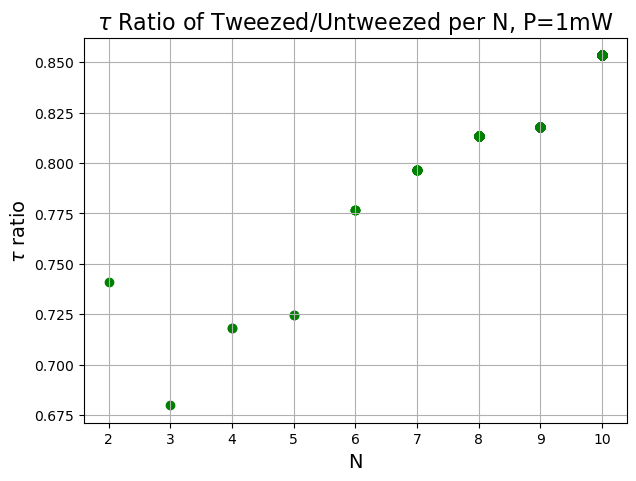

In [925]:
# Tweezed winners only
x_tweezed = []
y_tweezed = []

for N_val, winners in results_test:
    if not winners:
        continue
    for win in winners:
        tweezed_ion = _extract_tweezed_ion(win)
        if tweezed_ion is None:
            continue   # skip untweezed
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_tweezed.append(N_val)
        y_tweezed.append(abs(score))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_untweezed.append(N_val)
        y_untweezed.append(abs(score))

# Convert to arrays (safe if empty)
x_tweezed = np.asarray(x_tweezed, dtype=float)
y_tweezed = np.asarray(y_tweezed, dtype=float)
x_untweezed = np.asarray(x_untweezed, dtype=float)
y_untweezed = np.asarray(y_untweezed, dtype=float)

# Calculate the ratio (1/y_tweezed) / (1/y_untweezed) = y_untweezed / y_tweezed per N
Ns = np.unique(np.concatenate((x_tweezed, x_untweezed)))
ratios = []

for N in Ns:
    tweezed_scores = y_tweezed[x_tweezed == N]
    untweezed_scores = y_untweezed[x_untweezed == N]
    if len(tweezed_scores) == 0 or len(untweezed_scores) == 0:  # Avoid division by zero
        continue
    # Compute the ratio for each untweezed score to each tweezed score
    for tweezed_score in tweezed_scores:
        for untweezed_score in untweezed_scores:
            ratios.append((N, untweezed_score / tweezed_score))

# Separate the ratios into x and y for plotting
x_ratios = np.array([r[0] for r in ratios])
y_ratios = np.array([r[1] for r in ratios])

# Plot the ratios
plt.figure(figsize=(7, 5))
plt.scatter(x_ratios, y_ratios, color='green')
plt.xlabel('N',fontsize = 14)
plt.ylabel(r'$\tau$ ratio',fontsize = 14)
plt.title(r'$\tau$ Ratio of Tweezed/Untweezed per N, P=1mW',fontsize = 16)
plt.grid(True)
plt.show()

In [ ]:
# remove duplicates from y_ratios preserving original order
y_ratios_unique_P_1_mW = np.array(list(dict.fromkeys(y_ratios.tolist())))
print(y_ratios_unique_P_1_mW)

[0.74119283 0.67985736 0.71832498 0.72483768 0.77657545 0.79672239
 0.81321958 0.81802665 0.85345542]


In [ ]:
y_ref_2 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 2])
y_ref_3 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 3])
y_ref_4 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 4])
y_ref_5 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 5])
y_ref_6 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 6])
y_ref_7 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 7])
y_ref_8 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 8])
y_ref_9 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 9])
y_ref_10 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 10])


# Power sweep

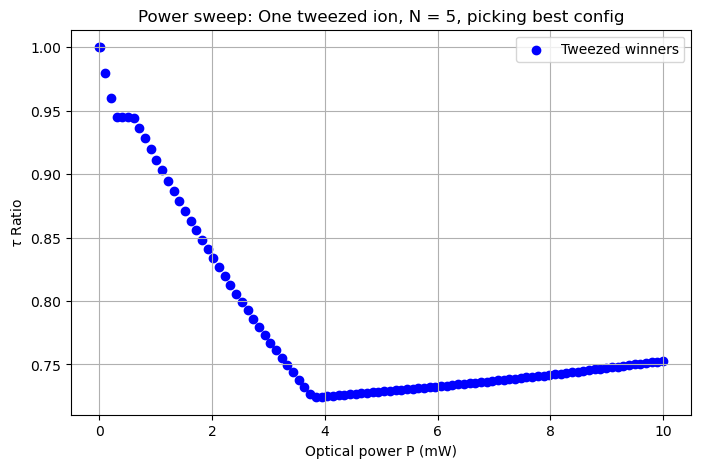

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 5
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3
P_list = np.linspace(1e-6, 0.01, 100)  # optical powers from 10 mW to 1 W

# --- Run power sweep using your tweezed-only function ---
results_power_sweep_5 = run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)

# --- Prepare data for plotting ---
x_tweezed = []
y_tweezed = []

for P_opt, winners in results_power_sweep_5:
    if not winners:
        continue
    # winners is a list of tuples: [((tweezed_ion, mapping, val, P_opt), (best_ion, best_mode)), ...]
    best_val = None  # Track the best (minimum) val for each P_opt
    for winner in winners:
        if len(winner) != 2:
            continue
        outer, inner = winner
        # outer == (tweezed_ion, mapping, val, P_opt)
        if len(outer) != 4:
            continue
        tweezed_ion, mapping, val, _ = outer  # P_opt is already available in the loop
        # inner == (best_ion, best_mode)
        if best_val is None or abs(val) < abs(best_val):
            best_val = val  # Update the best val for this P_opt

    if best_val is not None:
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(best_val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_5[0], marker='o',color = 'blue', label='Tweezed winners')
plt.scatter(0.0,1.00,marker = 'o',color = 'blue')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
#plt.xlim(0,0.5)
#plt.ylim(0.95,1.00)
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# --- prepare power list (don't reuse the name P_opt) ---
P_list = np.linspace(1e-6, 0.1, 2)  # 0.01 .. 1.0 W
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0
results_power_sweep_5_test = []
for Ni in range(5, 6):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_5_test.append((Ni, power_results))
results_power_sweep_5_test

[(5,
  [(1e-06,
    [((0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06), (3, 1)),
     ((0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06), (3, 3))]),
   (0.1, [((1, (1, 4, 0, 2, 3), -0.0587032592877252, 0.1), (2, 0))])])]

Finding where the configuration changes for the N=5 case

In [ ]:
from collections import defaultdict

data = results_power_sweep_5  # paste data here

occurrences = defaultdict(list)

# --- collect appearances ---
for P_opt, time_series in data:
    for entry in time_series:
        # Unpack the entry structure
        if len(entry) != 2:
            print(f"Unexpected entry structure: {entry}")
            continue
        outer, inner = entry
        if len(outer) != 4:
            print(f"Unexpected outer structure: {outer}")
            continue
        tweezed_ion, perm, score, _ = outer  # P_opt is already available in the loop
        best_ion, best_mode = inner

        # Create a key based on the structure
        key = (tuple(perm), score, (best_ion, best_mode))
        occurrences[key].append(P_opt)


# --- helper: convert timesteps to ranges ---
def make_ranges(times, tol=1e-9):
    times = sorted(times)
    ranges = []

    start = prev = times[0]

    for t in times[1:]:
        # consecutive if timestep spacing unchanged
        if abs(t - prev) <= 0.000101 + tol:
            prev = t
        else:
            ranges.append((start, prev))
            start = prev = t

    ranges.append((start, prev))
    return ranges


# --- keep only duplicates + build ranges ---
ranges_by_key = {}

for key, times in occurrences.items():
    if len(times) > 1:
        ranges_by_key[key] = make_ranges(times)


# --- display ---
for key, ranges in ranges_by_key.items():
    print(key)
    for r in ranges:
        print(f"  {r[0]} → {r[1]}")

In [ ]:
# ...existing code...
first_map = first_appearance_map_nested(results_power_sweep_5)

print(first_map)


ROW: N=1e-06, x=(0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06)
Full xb: ((0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06), (3, 1))
  entry: 3
  entry: 1

ROW: N=1e-06, x=(0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06)
Full xb: ((0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06), (3, 3))
  entry: 3
  entry: 3

ROW: N=0.00010200000000000001, x=(0, (0, 4, 2, 1, 3), 0.04424084518932712, 0.00010200000000000001)
Full xb: ((0, (0, 4, 2, 1, 3), 0.04424084518932712, 0.00010200000000000001), (3, 1))
  entry: 3
  entry: 1

ROW: N=0.00010200000000000001, x=(0, (0, 4, 2, 3, 1), 0.04424084518932712, 0.00010200000000000001)
Full xb: ((0, (0, 4, 2, 3, 1), 0.04424084518932712, 0.00010200000000000001), (3, 3))
  entry: 3
  entry: 3

ROW: N=0.00020300000000000003, x=(0, (0, 4, 2, 1, 3), 0.045145844906395484, 0.00020300000000000003)
Full xb: ((0, (0, 4, 2, 1, 3), 0.045145844906395484, 0.00020300000000000003), (3, 1))
  entry: 3
  entry: 1

ROW: N=0.00020300000000000003, x=(0, (0, 4, 2, 3, 1), 0.04514584

In [ ]:
first_map = first_appearance_map_nested(results_power_sweep_5)

# Pretty print sorted by x
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"a={a}, perm={perm} -> x={x}")



ROW: N=1e-06, x=(0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06)
Full xb: ((0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06), (3, 1))
  entry: 3
  entry: 1

ROW: N=1e-06, x=(0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06)
Full xb: ((0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06), (3, 3))
  entry: 3
  entry: 3

ROW: N=0.00010200000000000001, x=(0, (0, 4, 2, 1, 3), 0.04424084518932712, 0.00010200000000000001)
Full xb: ((0, (0, 4, 2, 1, 3), 0.04424084518932712, 0.00010200000000000001), (3, 1))
  entry: 3
  entry: 1

ROW: N=0.00010200000000000001, x=(0, (0, 4, 2, 3, 1), 0.04424084518932712, 0.00010200000000000001)
Full xb: ((0, (0, 4, 2, 3, 1), 0.04424084518932712, 0.00010200000000000001), (3, 3))
  entry: 3
  entry: 3

ROW: N=0.00020300000000000003, x=(0, (0, 4, 2, 1, 3), 0.045145844906395484, 0.00020300000000000003)
Full xb: ((0, (0, 4, 2, 1, 3), 0.045145844906395484, 0.00020300000000000003), (3, 1))
  entry: 3
  entry: 1

ROW: N=0.00020300000000000003, x=(0, (0, 4, 2, 3, 1), 0.04514584


ROW: N=1e-06, x=(0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06)
Full xb: ((0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06), (3, 1))
  entry: 3
  entry: 1

ROW: N=1e-06, x=(0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06)
Full xb: ((0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06), (3, 3))
  entry: 3
  entry: 3

ROW: N=0.00010200000000000001, x=(0, (0, 4, 2, 1, 3), 0.04424084518932712, 0.00010200000000000001)
Full xb: ((0, (0, 4, 2, 1, 3), 0.04424084518932712, 0.00010200000000000001), (3, 1))
  entry: 3
  entry: 1

ROW: N=0.00010200000000000001, x=(0, (0, 4, 2, 3, 1), 0.04424084518932712, 0.00010200000000000001)
Full xb: ((0, (0, 4, 2, 3, 1), 0.04424084518932712, 0.00010200000000000001), (3, 3))
  entry: 3
  entry: 3

ROW: N=0.00020300000000000003, x=(0, (0, 4, 2, 1, 3), 0.045145844906395484, 0.00020300000000000003)
Full xb: ((0, (0, 4, 2, 1, 3), 0.045145844906395484, 0.00020300000000000003), (3, 1))
  entry: 3
  entry: 1

ROW: N=0.00020300000000000003, x=(0, (0, 4, 2, 3, 1), 0.04514584

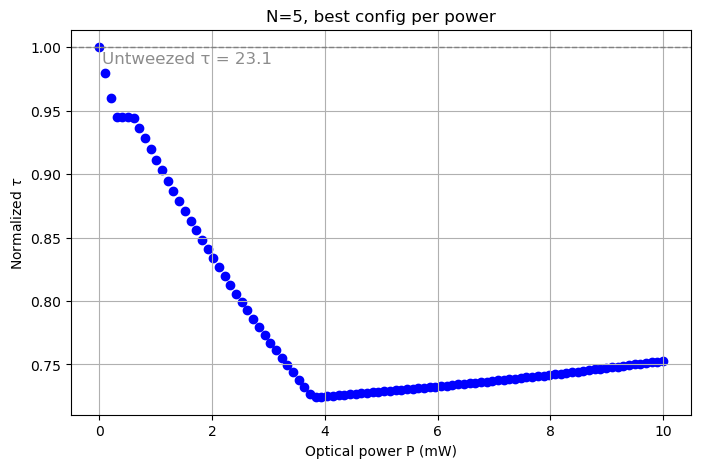

In [ ]:
# ...existing code...
plt.figure(figsize=(8,5))
ax = plt.gca()
x_mW = x_tweezed * 1e3
y_ref = y_ref_5[0]
ax.axhline(1.0, linestyle='--', color='gray', linewidth=1)
ax.scatter(x_mW, (1.0 / y_tweezed)/y_ref, marker='o', color='blue', label='Tweezed winners')

# draw vertical dotted lines at first appearance x-values (if available)
first_map = first_appearance_map_nested(results_power_sweep_5)
xs = [float(v) for v in first_map.values() if np.isfinite(v)]
xs_mW = np.array(xs) * 1e3
for xv in xs_mW:
    ax.axvline(x=xv, color='red', linestyle='-', linewidth=1, alpha=0.4)

# place label just underneath the dashed line and a little to the right
xlim = ax.get_xlim()
x_pos = xlim[0] + 0.05 * (xlim[1] - xlim[0])  # small right offset
ylim = ax.get_ylim()
y_offset = 0.01 * (ylim[1] - ylim[0])
ax.text(x_pos, 1.0 - y_offset, f'Untweezed τ = {y_ref:.3g}', color='gray',
        ha='left', va='top', fontsize=12, alpha=0.9)

ax.set_xlabel("Optical power P (mW)")
ax.set_ylabel("Normalized $\\tau$")
ax.set_title("N=5, best config per power")
ax.grid(True)
#ax.legend(loc = 'upper right')
plt.show()
# ...existing code...


ROW: N=1e-06, x=(0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06)
Full xb: ((0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06), (3, 1))
  entry: 3
  entry: 1

ROW: N=1e-06, x=(0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06)
Full xb: ((0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06), (3, 3))
  entry: 3
  entry: 3

ROW: N=0.00010200000000000001, x=(0, (0, 4, 2, 1, 3), 0.04424084518932712, 0.00010200000000000001)
Full xb: ((0, (0, 4, 2, 1, 3), 0.04424084518932712, 0.00010200000000000001), (3, 1))
  entry: 3
  entry: 1

ROW: N=0.00010200000000000001, x=(0, (0, 4, 2, 3, 1), 0.04424084518932712, 0.00010200000000000001)
Full xb: ((0, (0, 4, 2, 3, 1), 0.04424084518932712, 0.00010200000000000001), (3, 3))
  entry: 3
  entry: 3

ROW: N=0.00020300000000000003, x=(0, (0, 4, 2, 1, 3), 0.045145844906395484, 0.00020300000000000003)
Full xb: ((0, (0, 4, 2, 1, 3), 0.045145844906395484, 0.00020300000000000003), (3, 1))
  entry: 3
  entry: 1

ROW: N=0.00020300000000000003, x=(0, (0, 4, 2, 3, 1), 0.04514584

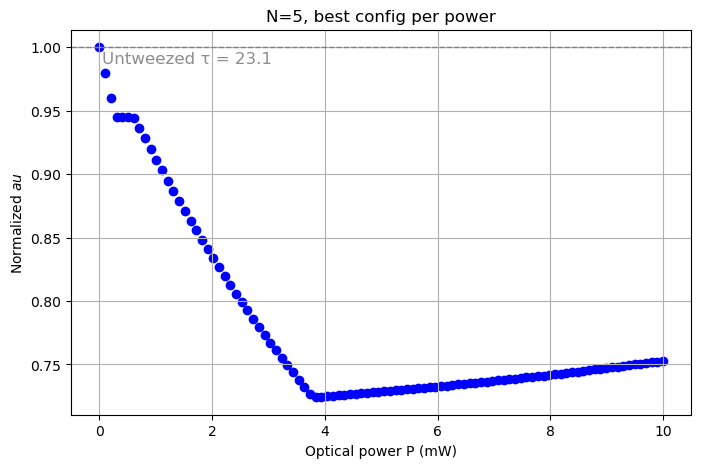

In [ ]:
# ...existing code...
plt.figure(figsize=(8,5))
ax = plt.gca()
x_mW = x_tweezed * 1e3
y_ref = 23.0701772
ax.axhline(1.0, linestyle='--', color='gray', linewidth=1)
ax.scatter(x_mW, (1.0 / y_tweezed)/y_ref, marker='o', color='blue', label='Tweezed winners')

# draw vertical dotted lines at first appearance x-values (if available)
first_map = first_appearance_map_nested(results_power_sweep_5)
xs = [float(v) for v in first_map.values() if np.isfinite(v)]
xs_mW = np.array(xs) * 1e3
for xv in xs_mW:
    ax.axvline(x=xv, color='red', linestyle='-', linewidth=1, alpha=0.4)


# place label just underneath the dashed line and a little to the right
xlim = ax.get_xlim()
x_pos = xlim[0] + 0.05 * (xlim[1] - xlim[0])  # small right offset
ylim = ax.get_ylim()
y_offset = 0.01 * (ylim[1] - ylim[0])
ax.text(x_pos, 1.0 - y_offset, f'Untweezed τ = {y_ref:.3g}', color='gray',
        ha='left', va='top', fontsize=12, alpha=0.9)

ax.set_xlabel("Optical power P (mW)")
ax.set_ylabel("Normalized $\tau$")
ax.set_title("N=5, best config per power")
ax.grid(True)
#ax.legend(loc = 'upper right')
plt.show()
# ...existing code...

In [ ]:
# print positions of red vertical lines (first-appearance x values)
try:
    fm = first_appearance_map(results_power_sweep_5)
except Exception:
    fm = globals().get("first_map", {})

# collect finite x values sorted
xs = sorted([float(v) for v in fm.values() if np.isfinite(v)])
xs_mW = [x * 1e3 for x in xs]

print("first_map (key -> first x in W):")
for k in sorted(fm.keys(), key=lambda kk: float(fm[kk])):
    print(f"{k} -> {fm[k]}")

print("\nRed lines at (W):", xs)
print("Red lines at (mW):", xs_mW)

first_map (key -> first x in W):

Red lines at (W): []
Red lines at (mW): []


In [ ]:
# checking what the config is for higher power # --- run sweep for desired N values (here only N=5) ---

# --- prepare power list (don't reuse the name P_opt) ---
P_list_test = np.linspace(1e-6, 0.1, 2)  # 0.01 .. 1.0 W
#print(P_list_test)
w0 = 1e-6
f_r = 1e6
f_rf_a = f_r / 3.0
results_power_sweep_5_test = []
for Ni in range(5, 6):
    # call with the whole list of powers
    power_results_test = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_r,
        f_rf_a,
        P_list_test,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    print(m)
    # store (N, power_results)
    results_power_sweep_5_test.append((Ni, power_results_test))


6.635945850290917e-26


In [ ]:
# --- prepare power list (don't reuse the name P_opt) ---
P_list = np.linspace(1e-6, 1, 2)  # 0.01 .. 1.0 W
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_5_check = []
for Ni in range(5, 6):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_5_check.append((Ni, power_results))

In [ ]:
results_power_sweep_5_check

[(5,
  [(1e-06,
    [((0, (0, 4, 2, 1, 3), 0.04335468251754514), (3, 1)),
     ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (3, 3))]),
   (1.0, [((1, (1, 4, 0, 2, 3), -0.05902445007246621), (2, 0))])])]

In [ ]:
test5.loc["Tweezed ions"]

N                                                                                                                                                5
Tweezed ions                                                                                                                                  (2,)
P_per_tweezer (W)                                                                                                                              1.0
Combined radial frequencies                        [6283185.307179586, 6283185.307179586, 8929726.569216797, 6283185.307179586, 6283185.307179586]
Mode0_freq                                                                                                                          1417284.396056
Mode0_eigvec                   [-0.0005432996282700573, -0.004980112701343629, -0.9999749029880659, -0.004980112701354534, -0.0005432996282637425]
Mode1_freq                                                                                                            

In [ ]:
# access 'Mode2_eigvec' for the third row (index 2)
val = [
	test5.iloc[0]["Mode0_eigvec"][0],
	test5.iloc[0]["Mode1_eigvec"][4],
	test5.iloc[0]["Mode2_eigvec"][2],
	test5.iloc[0]["Mode3_eigvec"][1],
	test5.iloc[0]["Mode4_eigvec"][3],
]
# round each element (round doesn't work on lists)
val_rounded = [round(float(x), 4) for x in val]
val_rounded

[0.4472, 0.6395, 0.5143, -0.6395, 0.4704]

In [ ]:
test5

,N,Tweezed ions,P_per_tweezer (W),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode1_freq,Mode1_eigvec,Mode2_freq,Mode2_eigvec,Mode3_freq,Mode3_eigvec,Mode4_freq,Mode4_eigvec
0,5,(),0.000000,"[6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.04334600429119, 0.04334600429119033, 0.0433460042911855, 0.04334600429118624, 0.043346004291188664]",998591.769784,"[-0.06203018222954044, -0.02925868701700628, -2.615105808331226e-13, 0.029258687016509008, 0.06203018223030257]",996604.410858,"[-0.05220056681378907, 0.027235201841101512, 0.049930729943198957, 0.027235201843212008, -0.05220056681371517]",994120.048940,"[0.029324418454629252, -0.06216953684378651, -1.1257200677864483e-12, 0.06216953684360876, -0.029324418453322343]",991183.598917,"[-0.01017746551532493, 0.04579923173115059, -0.07124353243147753, 0.04579923173045114, -0.010177465514803497]"
1,5,"(0,)",0.000001,"[6283188.511095018, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.04335468251754514, 0.04334719742234898, 0.04334439128946852, 0.04334259133257232, 0.04334114651858909]",998591.978639,"[-0.06203098339115079, -0.029250200981304268, 8.578726075208602e-06, 0.029264427272996912, 0.06203065890438422]",996604.558746,"[-0.052194534627995295, 0.0272416792628559, 0.04993191843405388, 0.02723234668564746, -0.052203557976198474]",994120.095610,"[0.029320843407412957, -0.06217003312621696, 1.5541517265739068e-06, 0.0621703323266683, -0.02932524702961687]",991183.604539,"[-0.010176618853631109, 0.04579899695404755, -0.07124368030370624, 0.04579941219247469, -0.010177518791917896]"
2,5,"(1,)",0.000001,"[6283185.307179586, 6283188.511095018, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.04334719748285499, 0.043350043853894016, 0.04334607574287592, 0.04334410105711959, 0.04334259188587376]",998591.816251,"[-0.06202617965923966, -0.029258975538984135, 1.7317759375441703e-06, 0.029261136225238817, 0.06203288966490535]",996604.451122,"[-0.05220394688110711, 0.027236611933858162, 0.04992902201034849, 0.02723329270690487, -0.05219907692452679]",994120.258731,"[0.029325470689226852, -0.06216919899364953, 6.674893104476182e-06, 0.06216856625559897, -0.02932610533849238]",991183.712760,"[-0.010176408956621849, 0.045794790833468164, -0.07124468559224117, 0.045801920923154854, -0.010178277628345465]"


In [ ]:
results_test

[0.0433, 0.062, 0.0499, -0.0622, 0.0458]

## Showing the optimal configuration for N=6

In [ ]:
print(results[6-2])
#print(results_high_P[6-2])
#print(untweezed_results[6-2])

(6, [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147861, [0.1]), (3, 4))])


In [ ]:
N = 6
f_rf_r = 1e6
w_rf_a = f_rf_r/3 * 2*pi
indices = (2,5,0,4,1,3)
tweezed_ions = 2
w_rf_r = f_rf_r * 2 * np.pi

ueq = ion_spacing(N,w_rf_a)[0]

w0 = 1e-6
P0 = 1


U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
w_tw_r = omega_tweezer_r(U,w0,m)

w_rf_combined = np.full((N,), w_rf_r)
w_rf_combined[tweezed_ions] = np.sqrt(w_tw_r**2 + w_rf_r**2)

data_N6 = mode_calc_r(m,w_rf_combined,ueq,N)
print(data_N6)

[(1255704.4013654306, array([-0.0845683 , -0.2438689 , -0.92793597, -0.24760568, -0.09713705,
       -0.03958305])), (951351.2556375061, array([-0.11404744, -0.08830807, -0.11425732,  0.22505008,  0.50855099,
        0.81047423])), (924088.6109673303, array([-0.91227995, -0.34467261,  0.17387834,  0.03560102, -0.0410669 ,
       -0.1255328 ])), (769055.9334767964, array([-0.07909169,  0.1073797 ,  0.15816996, -0.51771072, -0.61794036,
        0.55436603])), (645392.1744376093, array([ 0.37547283, -0.89317837,  0.20355198,  0.02927549, -0.12614056,
        0.05523262])), (422526.77548757003, array([-0.01874388,  0.06806193, -0.17086626,  0.78606298, -0.57662125,
        0.12423316]))]


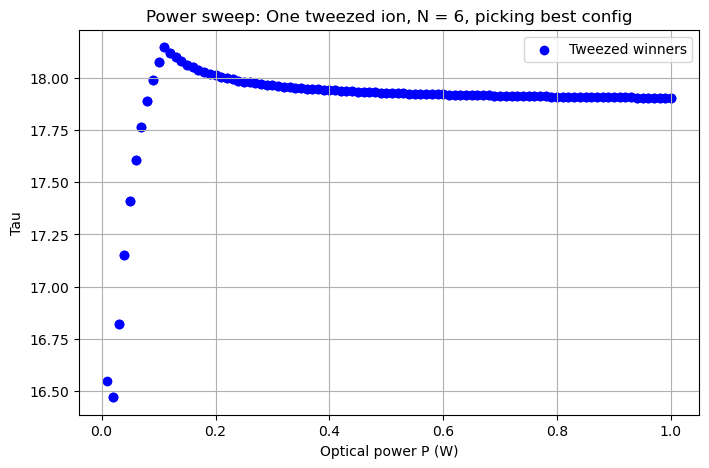

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 6
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3
P_list = np.linspace(10e-3, 1, 100)  # optical powers from 10 mW to 1 W

# --- Run power sweep using your tweezed-only function ---
results_power_sweep_6 = run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)

# --- Prepare data for plotting ---
x_tweezed = []
y_tweezed = []

for P_opt, winners in results_power_sweep_6:
    if not winners:
        continue
    for (tweezed_ion, mapping, val), (best_ion, best_mode) in winners:
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, 1/y_tweezed, marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Tau")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config")
plt.grid(True)
plt.legend()
plt.show()


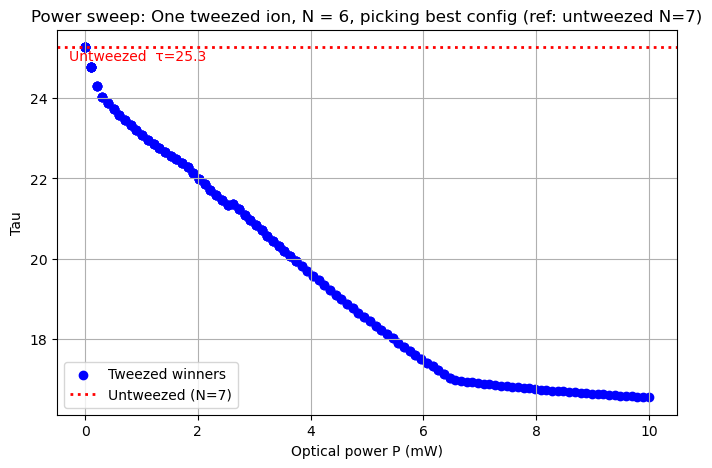

In [ ]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 6
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3
P_list = np.linspace(1e-6, 0.01, 100)  # optical powers from 10 mW to 1 W

# --- Run power sweep using your tweezed-only function ---
results_power_sweep_6 = run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)

# --- Prepare data for plotting ---
x_tweezed = []
y_tweezed = []

for P_opt, winners in results_power_sweep_6:
    if not winners:
        continue
    for (tweezed_ion, mapping, val), (best_ion, best_mode) in winners:
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- find untweezed reference tau from untweezed_results for N=7 ---
unt_ref = np.nan
for N_val, winners in globals().get("untweezed_results", []):
    try:
        if int(N_val) == 6 and winners:
            w = winners[0]
            if ' _extract_score_from_win' in globals():  # fallback if helper not present
                try:
                    ref_score = _extract_score_from_win(w)
                except Exception:
                    ref_score = None
            else:
                # robust extraction similar to other cells
                if isinstance(w, (list, tuple)):
                    if isinstance(w[0], (list, tuple)) and len(w[0]) >= 3:
                        ref_score = w[0][2]
                    elif len(w) >= 3:
                        ref_score = w[2]
                    else:
                        ref_score = None
                else:
                    ref_score = None
            if ref_score is not None:
                ref_score = float(ref_score)
                if ref_score != 0:
                    unt_ref = 1.0 / abs(ref_score)
            break
    except Exception:
        continue

# --- plot (x-axis in mW) ---
plt.figure(figsize=(8,5))
if x_tweezed.size:
    plt.scatter(x_tweezed * 1e3, 1.0 / y_tweezed, marker='o', color='blue', label='Tweezed winners')
if np.isfinite(unt_ref):
    plt.axhline(unt_ref, color='red', linestyle=':', linewidth=2, label='Untweezed (N=7)')
    plt.annotate(f'Untweezed  τ={unt_ref:.3g}', xy=(0.02, 0.95), xycoords='axes fraction',
                 ha='left', va='top', color='red')
plt.xlabel("Optical power P (mW)")
plt.ylabel("Tau")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config (ref: untweezed N=7)")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

In [ ]:
results_power_sweep_6

[(1e-06,
  [((0, (0, 5, 2, 1, 4, 3), 0.03957693147581805), (0, 0)),
   ((0, (0, 5, 2, 4, 1, 3), 0.03957693147581805), (0, 0)),
   ((0, (0, 5, 3, 1, 4, 2), 0.03957693147581805), (0, 0)),
   ((0, (0, 5, 3, 4, 1, 2), 0.03957693147581805), (0, 0)),
   ((5, (5, 0, 2, 1, 4, 3), 0.03957693147581852), (0, 5)),
   ((5, (5, 0, 2, 4, 1, 3), 0.03957693147581852), (0, 5)),
   ((5, (5, 0, 3, 1, 4, 2), 0.03957693147581852), (0, 5)),
   ((5, (5, 0, 3, 4, 1, 2), 0.03957693147581852), (0, 5))]),
 (0.00010200000000000001,
  [((0, (0, 5, 2, 1, 4, 3), 0.04035635241389928), (0, 0)),
   ((0, (0, 5, 2, 4, 1, 3), 0.04035635241389928), (0, 0)),
   ((0, (0, 5, 3, 1, 4, 2), 0.04035635241389928), (0, 0)),
   ((0, (0, 5, 3, 4, 1, 2), 0.04035635241389928), (0, 0)),
   ((5, (5, 0, 2, 1, 4, 3), 0.04035635241390715), (0, 5)),
   ((5, (5, 0, 2, 4, 1, 3), 0.04035635241390715), (0, 5)),
   ((5, (5, 0, 3, 1, 4, 2), 0.04035635241390715), (0, 5)),
   ((5, (5, 0, 3, 4, 1, 2), 0.04035635241390715), (0, 5))]),
 (0.0002030000000

In [ ]:
def first_appearance_map(data):
    """
    Returns a dict mapping (a, permutation) -> first x-value where it appears.
    Assumes `data` is ordered by increasing x.
    """
    first_x = {}

    for x, entries in data:
        for ((a, permutation, _), _) in entries:
            key = (a, tuple(permutation))
            if key not in first_x:
                first_x[key] = x

    return first_x


In [ ]:
# ...existing code...
def first_appearance_map(data):
    """
    Returns a dict mapping (a, permutation) -> first x-value where it appears.
    Assumes `data` is ordered by increasing x.
    """
    first_x = {}

    for x, entries in data:
        for ((a, permutation, _), _) in entries:
            key = (a, tuple(permutation))
            if key not in first_x:
                first_x[key] = x

    return first_x

first_map = first_appearance_map(results_power_sweep_6)

# Pretty-print sorted by x and show full winner rows where each first-appearance occurs
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"\nKey (a={a}, perm={perm}) -> first x = {x}")
    found_block = False
    for p_opt, winners in results_power_sweep_6:
        try:
            match = np.isclose(float(p_opt), float(x))
        except Exception:
            match = (p_opt == x)
        if not match:
            continue
        found_block = True
        print(f"  Matching block: P = {p_opt}, winners_count = {len(winners)}")
        for idx, entry in enumerate(winners):
            print(f"    entry[{idx}]: {entry}")
            # attempt to show the (a, perm) for this entry if present
            try:
                e_a = entry[0][0]
                e_perm = tuple(entry[0][1])
                print(f"      -> entry key = (a={e_a}, perm={e_perm})", end="")
                if (e_a, e_perm) == (a, perm):
                    print("  <-- FIRST APPEARANCE!")
                else:
                    print("")
            except Exception:
                pass
    if not found_block:
        print("  No matching P block found in results_power_sweep_6 for this x")
# ...existing code...


Key (a=0, perm=(0, 5, 2, 1, 4, 3)) -> first x = 1e-06
  Matching block: P = 1e-06, winners_count = 8
    entry[0]: ((0, (0, 5, 2, 1, 4, 3), 0.03957693147581805), (0, 0))
      -> entry key = (a=0, perm=(0, 5, 2, 1, 4, 3))  <-- FIRST APPEARANCE!
    entry[1]: ((0, (0, 5, 2, 4, 1, 3), 0.03957693147581805), (0, 0))
      -> entry key = (a=0, perm=(0, 5, 2, 4, 1, 3))
    entry[2]: ((0, (0, 5, 3, 1, 4, 2), 0.03957693147581805), (0, 0))
      -> entry key = (a=0, perm=(0, 5, 3, 1, 4, 2))
    entry[3]: ((0, (0, 5, 3, 4, 1, 2), 0.03957693147581805), (0, 0))
      -> entry key = (a=0, perm=(0, 5, 3, 4, 1, 2))
    entry[4]: ((5, (5, 0, 2, 1, 4, 3), 0.03957693147581852), (0, 5))
      -> entry key = (a=5, perm=(5, 0, 2, 1, 4, 3))
    entry[5]: ((5, (5, 0, 2, 4, 1, 3), 0.03957693147581852), (0, 5))
      -> entry key = (a=5, perm=(5, 0, 2, 4, 1, 3))
    entry[6]: ((5, (5, 0, 3, 1, 4, 2), 0.03957693147581852), (0, 5))
      -> entry key = (a=5, perm=(5, 0, 3, 1, 4, 2))
    entry[7]: ((5, (5, 0, 3,

In [ ]:
first_map = first_appearance_map(results_power_sweep_6)

# Pretty-print sorted by x
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"{(a, perm)} -> {x}")

(0, (0, 5, 2, 1, 4, 3)) -> 1e-06
(0, (0, 5, 2, 4, 1, 3)) -> 1e-06
(0, (0, 5, 3, 1, 4, 2)) -> 1e-06
(0, (0, 5, 3, 4, 1, 2)) -> 1e-06
(5, (5, 0, 2, 1, 4, 3)) -> 1e-06
(5, (5, 0, 2, 4, 1, 3)) -> 1e-06
(5, (5, 0, 3, 1, 4, 2)) -> 1e-06
(5, (5, 0, 3, 4, 1, 2)) -> 1e-06
(1, (1, 0, 5, 4, 2, 3)) -> 0.001819
(1, (1, 5, 0, 4, 2, 3)) -> 0.001819
(4, (4, 0, 5, 1, 3, 2)) -> 0.001819
(4, (4, 5, 0, 1, 3, 2)) -> 0.001819
(2, (2, 0, 5, 4, 1, 3)) -> 0.0027280000000000004
(2, (2, 5, 0, 4, 1, 3)) -> 0.0027280000000000004
(3, (3, 0, 5, 1, 4, 2)) -> 0.0027280000000000004
(3, (3, 5, 0, 1, 4, 2)) -> 0.0027280000000000004


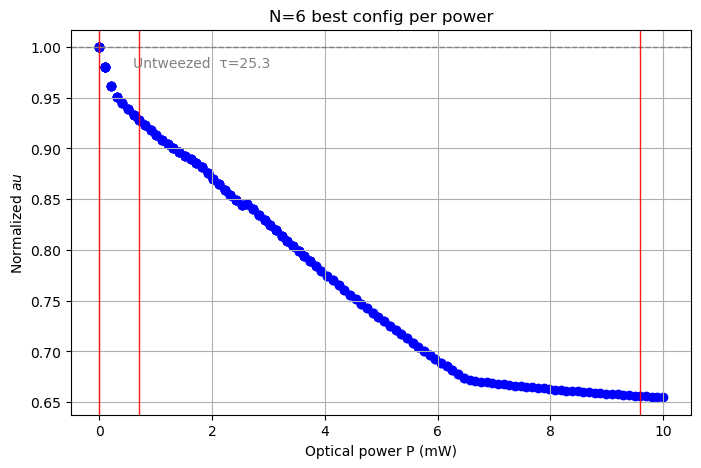

(0, (0, 5, 2, 1, 4, 3)) -> 1e-06
(0, (0, 5, 2, 4, 1, 3)) -> 1e-06
(0, (0, 5, 3, 1, 4, 2)) -> 1e-06
(0, (0, 5, 3, 4, 1, 2)) -> 1e-06
(5, (5, 0, 2, 1, 4, 3)) -> 1e-06
(5, (5, 0, 2, 4, 1, 3)) -> 1e-06
(5, (5, 0, 3, 1, 4, 2)) -> 1e-06
(5, (5, 0, 3, 4, 1, 2)) -> 1e-06
(1, (1, 0, 5, 4, 2, 3)) -> 0.001819
(1, (1, 5, 0, 4, 2, 3)) -> 0.001819
(4, (4, 0, 5, 1, 3, 2)) -> 0.001819
(4, (4, 5, 0, 1, 3, 2)) -> 0.001819
(2, (2, 0, 5, 4, 1, 3)) -> 0.0027280000000000004
(2, (2, 5, 0, 4, 1, 3)) -> 0.0027280000000000004
(3, (3, 0, 5, 1, 4, 2)) -> 0.0027280000000000004
(3, (3, 5, 0, 1, 4, 2)) -> 0.0027280000000000004


In [ ]:
#need to add in x=0.0026270000000000004 as a red line and 0.0065660000000000015
y_ref_6 = 25.27211292
fig, ax = plt.subplots(figsize=(8,5))
if x_tweezed.size:
    ax.scatter(x_tweezed * 1e3, (1.0 / y_tweezed)/y_ref_6, marker='o', color='blue', label='Tweezed winners')

    ax.axhline(1, color='gray', linestyle='--', linewidth=1)
    ax.annotate(f'Untweezed  τ={unt_ref:.3g}', xy=(0.1, 0.93), xycoords='axes fraction',
                ha='left', va='top', color='gray')

# draw vertical green lines at first-appearance x positions (mW)
for xv in np.unique(xs_mW):
    ax.axvline(x=xv, color='red', linewidth=1, alpha=0.9)

ax.set_xlabel("Optical power P (mW)")
ax.set_ylabel("Normalized $\tau$")
ax.set_title("N=6 best config per power")
ax.grid(True)
#ax.legend()
plt.show()

# Pretty-print sorted by x (uses first_map computed above)
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"{(a, perm)} -> {x}")
# ...existing code...

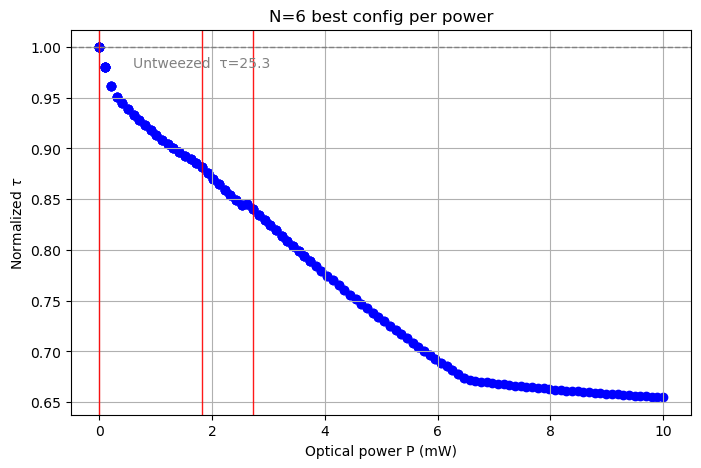

(0, (0, 5, 2, 1, 4, 3)) -> 1e-06
(0, (0, 5, 2, 4, 1, 3)) -> 1e-06
(0, (0, 5, 3, 1, 4, 2)) -> 1e-06
(0, (0, 5, 3, 4, 1, 2)) -> 1e-06
(5, (5, 0, 2, 1, 4, 3)) -> 1e-06
(5, (5, 0, 2, 4, 1, 3)) -> 1e-06
(5, (5, 0, 3, 1, 4, 2)) -> 1e-06
(5, (5, 0, 3, 4, 1, 2)) -> 1e-06
(1, (1, 0, 5, 4, 2, 3)) -> 0.001819
(1, (1, 5, 0, 4, 2, 3)) -> 0.001819
(4, (4, 0, 5, 1, 3, 2)) -> 0.001819
(4, (4, 5, 0, 1, 3, 2)) -> 0.001819
(2, (2, 0, 5, 4, 1, 3)) -> 0.0027280000000000004
(2, (2, 5, 0, 4, 1, 3)) -> 0.0027280000000000004
(3, (3, 0, 5, 1, 4, 2)) -> 0.0027280000000000004
(3, (3, 5, 0, 1, 4, 2)) -> 0.0027280000000000004


In [ ]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

y_ref_6 = 25.27211292

# recompute first_map from results to ensure consistency
first_map = first_appearance_map(results_power_sweep_6)

# group keys by their first-appearance x value (in W)
x_to_keys = defaultdict(list)
for (a, perm), x in first_map.items():
    try:
        if np.isfinite(float(x)):
            x_to_keys[float(x)].append((a, tuple(perm)))
    except Exception:
        continue

xs = sorted(x_to_keys.keys())
xs_mW = np.array(xs) * 1e3

fig, ax = plt.subplots(figsize=(8,5))
if x_tweezed.size:
    ax.scatter(x_tweezed * 1e3, (1.0 / y_tweezed)/y_ref_6, marker='o', color='blue', label='Tweezed winners')

ax.axhline(1, color='gray', linestyle='--', linewidth=1)
ax.annotate(f'Untweezed  τ={unt_ref:.3g}', xy=(0.1, 0.93), xycoords='axes fraction',
            ha='left', va='top', color='gray')

# draw vertical green lines at first-appearance x positions (mW) and annotate
for x_w in xs:
    x_mW = x_w * 1e3
    ax.axvline(x=x_mW, color='red', linewidth=1, alpha=0.9)


ax.set_xlabel("Optical power P (mW)")
ax.set_ylabel("Normalized $\\tau$")
ax.set_title("N=6 best config per power")
ax.grid(True)
# ax.legend()
plt.show()

# Pretty-print sorted by x (uses first_map computed above)
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"{(a, perm)} -> {x}")
# ...existing code...

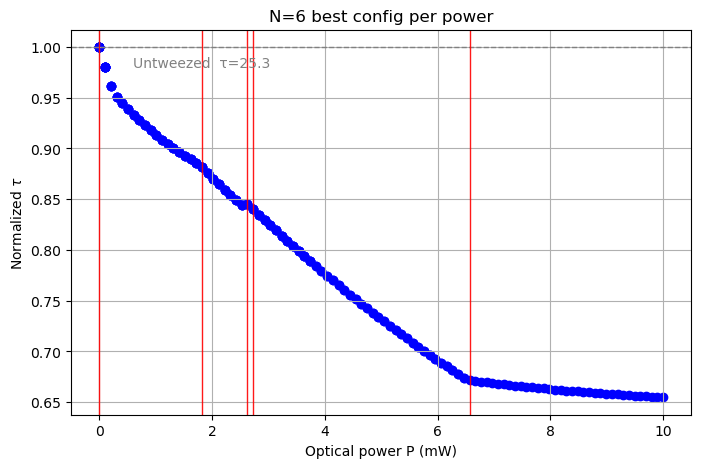

(0, (0, 5, 2, 1, 4, 3)) -> 1e-06
(0, (0, 5, 2, 4, 1, 3)) -> 1e-06
(0, (0, 5, 3, 1, 4, 2)) -> 1e-06
(0, (0, 5, 3, 4, 1, 2)) -> 1e-06
(5, (5, 0, 2, 1, 4, 3)) -> 1e-06
(5, (5, 0, 2, 4, 1, 3)) -> 1e-06
(5, (5, 0, 3, 1, 4, 2)) -> 1e-06
(5, (5, 0, 3, 4, 1, 2)) -> 1e-06
(1, (1, 0, 5, 4, 2, 3)) -> 0.001819
(1, (1, 5, 0, 4, 2, 3)) -> 0.001819
(4, (4, 0, 5, 1, 3, 2)) -> 0.001819
(4, (4, 5, 0, 1, 3, 2)) -> 0.001819
(2, (2, 0, 5, 4, 1, 3)) -> 0.0027280000000000004
(2, (2, 5, 0, 4, 1, 3)) -> 0.0027280000000000004
(3, (3, 0, 5, 1, 4, 2)) -> 0.0027280000000000004
(3, (3, 5, 0, 1, 4, 2)) -> 0.0027280000000000004


In [ ]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

y_ref_6 = 25.27211292

# recompute first_map from results to ensure consistency
first_map = first_appearance_map(results_power_sweep_6)

# group keys by their first-appearance x value (in W)
x_to_keys = defaultdict(list)
for (a, perm), x in first_map.items():
    try:
        if np.isfinite(float(x)):
            x_to_keys[float(x)].append((a, tuple(perm)))
    except Exception:
        continue

xs = sorted(x_to_keys.keys())
xs_mW = np.array(xs) * 1e3

fig, ax = plt.subplots(figsize=(8,5))
if x_tweezed.size:
    ax.scatter(x_tweezed * 1e3, (1.0 / y_tweezed)/y_ref_6, marker='o', color='blue', label='Tweezed winners')

ax.axhline(1, color='gray', linestyle='--', linewidth=1)
ax.annotate(f'Untweezed  τ={unt_ref:.3g}', xy=(0.1, 0.93), xycoords='axes fraction',
            ha='left', va='top', color='gray')

# draw vertical red lines at first-appearance x positions (mW)
for x_w in xs:
    x_mW = x_w * 1e3
    ax.axvline(x=x_mW, color='red', linewidth=1, alpha=0.9)

# add the two requested manual red lines (values provided in W -> convert to mW)
for w in (0.0026270000000000004, 0.0065660000000000015):
    ax.axvline(x=w * 1e3, color='red', linestyle='-', linewidth=1, alpha=0.9)

ax.set_xlabel("Optical power P (mW)")
ax.set_ylabel("Normalized $\\tau$")
ax.set_title("N=6 best config per power")
ax.grid(True)
# ax.legend()
plt.show()

# Pretty-print sorted by x (uses first_map computed above)
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"{(a, perm)} -> {x}")
# ...existing code...

# Finding optimal powers for N=3 to N=31 and plotting midcircuit results


In [ ]:
powersweep = np.linspace(1e-6, 0.1, 100)

# Initialize dictionaries to store results
sum_inverse_middle_per_N = {N: [] for N in range(3, 31)}
corresponding_power_per_N = {N: None for N in range(3, 31)}

for p in powersweep:
    for N in range(3, 31):
        # Call the function and get the output
        output = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N, f_rf_r, f_rf_a, p, w0
        )

        # Extract "sum_inverse_middle" if the output is valid
        if isinstance(output, pd.DataFrame) and not output.empty:
            sum_inverse_middle = output["sum_inverse_middle"].iloc[0]
            sum_inverse_middle_per_N[N].append((p, sum_inverse_middle))

# Find the minimum "sum_inverse_middle" and corresponding power for each N
for N, values in sum_inverse_middle_per_N.items():
    if values:  # Ensure there are values to process
        min_power, min_sum_inverse = min(values, key=lambda x: x[1])
        corresponding_power_per_N[N] = min_power


In [ ]:
# Display the power corresponding to the lowest "sum_inverse_middle" for each ion number
print("Ion Number (N) -> Power with Lowest sum_inverse_middle")
for N, power in corresponding_power_per_N.items():
    print(f"N={N}: Power={power:.6f} W" if power is not None else f"N={N}: No valid data")

Ion Number (N) -> Power with Lowest sum_inverse_middle
N=3: Power=0.000001 W
N=4: Power=0.002021 W
N=5: Power=0.001011 W
N=6: Power=0.002021 W
N=7: Power=0.002021 W
N=8: Power=0.002021 W
N=9: Power=0.003031 W
N=10: Power=0.003031 W
N=11: Power=0.003031 W
N=12: Power=0.004041 W
N=13: Power=0.004041 W
N=14: Power=0.004041 W
N=15: Power=0.004041 W
N=16: Power=0.005051 W
N=17: Power=0.005051 W
N=18: Power=0.005051 W
N=19: Power=0.005051 W
N=20: Power=0.006062 W
N=21: Power=0.006062 W
N=22: Power=0.006062 W
N=23: Power=0.006062 W
N=24: Power=0.006062 W
N=25: Power=0.007072 W
N=26: Power=0.007072 W
N=27: Power=0.007072 W
N=28: Power=0.007072 W
N=29: Power=0.007072 W
N=30: Power=0.007072 W


In [ ]:
# Assuming `corresponding_power_per_N` contains the mapping of Ion Number (N) to Power with lowest sum_inverse_middle
# Extract the power values into a list
power_values_list = np.array(list(corresponding_power_per_N.values()))

# Display the list
print(power_values_list*1e3) #mW

[1.00000000e-03 2.02118182e+00 1.01109091e+00 2.02118182e+00
 2.02118182e+00 2.02118182e+00 3.03127273e+00 3.03127273e+00
 3.03127273e+00 4.04136364e+00 4.04136364e+00 4.04136364e+00
 4.04136364e+00 5.05145455e+00 5.05145455e+00 5.05145455e+00
 5.05145455e+00 6.06154545e+00 6.06154545e+00 6.06154545e+00
 6.06154545e+00 6.06154545e+00 7.07163636e+00 7.07163636e+00
 7.07163636e+00 7.07163636e+00 7.07163636e+00 7.07163636e+00]


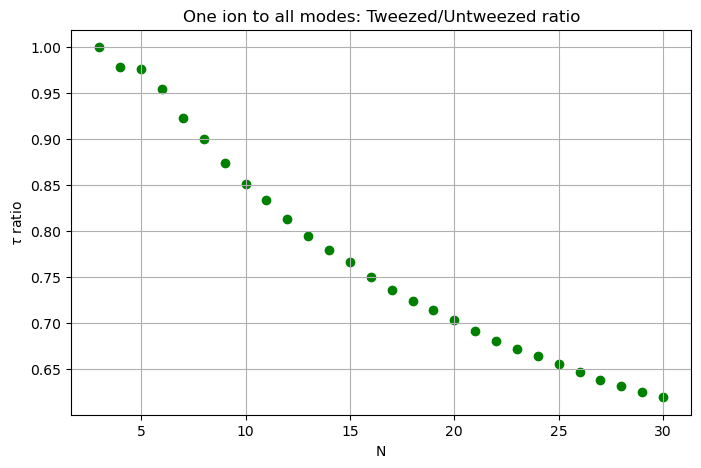

In [ ]:
N_values = range(3, 31)  # Define the range of N values
P_values = power_values_list

# Ensure the lengths of N_values and P_values match
if len(P_values) < len(N_values):
    raise ValueError("The list P_values must have at least as many elements as N_values.")

dfs = []
many_N = []

# Iterate over N and the corresponding P value
for N, P in zip(N_values, P_values):
    P_current = [P]  # Wrap P in a list to match the expected input format
    test_loop = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P_current,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # Attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)

# Untweezed loop
dfs_untweezed = []
many_N_untweezed = []

for N, P in zip(N_values, P_values):
    P_current = [P]  # Wrap P in a list to match the expected input format
    test_loop = midcircuit_modes_untweezed(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P_current,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # Attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)

# Combine per-N DataFrames if not already done
combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

# Calculate the ratio of tweezed to untweezed
common_N = set(Ns_t).intersection(Ns_u)
ratios = {N: vals_t[np.where(Ns_t == N)[0][0]] / vals_u[np.where(Ns_u == N)[0][0]] for N in common_N}

# Sort the data by N for plotting
sorted_N = sorted(common_N)
sorted_ratios = [ratios[N] for N in sorted_N]

plt.figure(figsize=(8, 5))
#if Ns_t.size:
#    plt.scatter(Ns_t, vals_t, marker='o', linestyle='-', color='C1', label='Tweezed')
#if Ns_u.size:
#    plt.scatter(Ns_u, vals_u, marker='s', linestyle='--', color='C0', label='Untweezed')
plt.scatter(sorted_N, sorted_ratios, marker='o',  color='green')
plt.xlabel("N")
plt.ylabel(r"$\tau$ ratio")
plt.title("One ion to all modes: Tweezed/Untweezed ratio")
plt.grid(True)
plt.show()

## Checking what the results look like for N=3

In [ ]:
coolant_3 = midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        3,
        f_rf_r,
        f_rf_a,
        power_values_list[0],
        w0,
    )

In [ ]:
coolant_3.keys()

Index(['Tweezed Ion', 'Coolant Ion', 'Mode couplings', 'inverse_mode_couplings', 'sum_inverse_middle'], dtype='object')

In [ ]:
print(int(coolant_3['Coolant Ion']))

2


In [ ]:
Coolant_ions = []
Tweezed_ions = []
for i in range(3,31):
    df = midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        i,
        f_rf_r,
        f_rf_a,
        power_values_list[i-3],
        w0,
    )
    Coolant_ions.append(int(df['Coolant Ion']))
    Tweezed_ions.append(int(df['Tweezed Ion']))


In [ ]:
print(Coolant_ions)
print(Tweezed_ions)

[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
midcircuit_modes_untweezed_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        3,
        f_rf_r,
        f_rf_a,
        power_values_list[0],
        w0,
    )

,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,NaN,0,"[0.05595945091480255, -0.06858435881036137, 0.03963641089674457]","[17.87008241954492, 14.58058393117069, 25.229327715999943]",57.679994
1,NaN,2,"[0.055959450914800805, 0.06858435881036089, 0.03963641089674782]","[17.87008241954548, 14.580583931170793, 25.229327715997876]",57.679994


# Finding optimal powers across N

### N=7

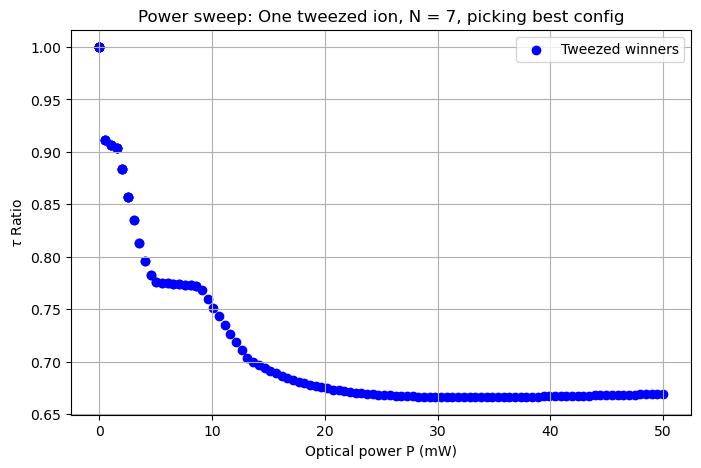

In [ ]:
P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_7 = []
for Ni in range(7, 8):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_7.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_7: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_7:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_7[0], marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 7, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
P_opt_7_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_7[0])]*1e3
print(P_opt_7_mW )

32.828626262626265


## Checking optimal power for N = 2

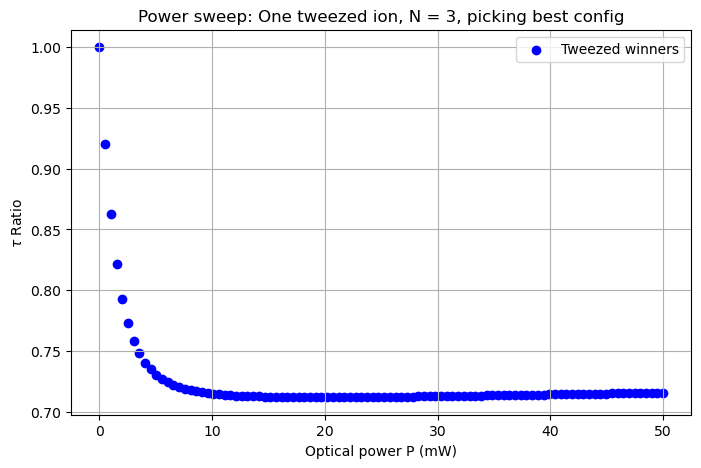

In [ ]:
# add in N=2 back in 
P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_2= []
for Ni in range(2, 3):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_2.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_3: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_2:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_2[0], marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 3, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
P_opt_2_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_2[0])]*1e3
print(P_opt_2_mW )

19.697575757575763


## N=3

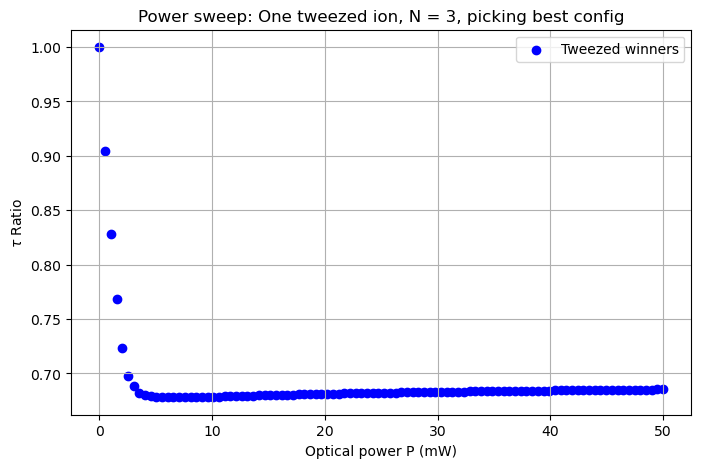

In [ ]:
P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_3 = []
for Ni in range(3, 4):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_3.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_3: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_3:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_3[0], marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 3, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
P_opt_3_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_3[0])]*1e3
print(P_opt_3_mW )

7.0715656565656575


## N = 4

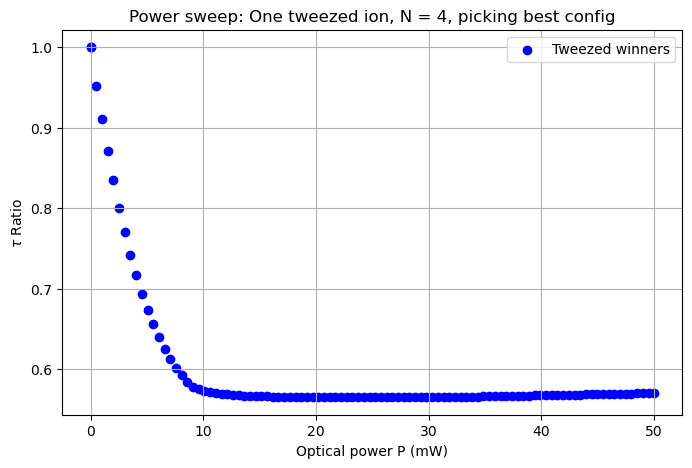

In [ ]:
P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_4 = []
for Ni in range(4, 5):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_4.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_4: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_4:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_4[0], marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 4, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
P_opt_4_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_4[0])]*1e3 
print(P_opt_4_mW)

21.71773737373738


## N = 5

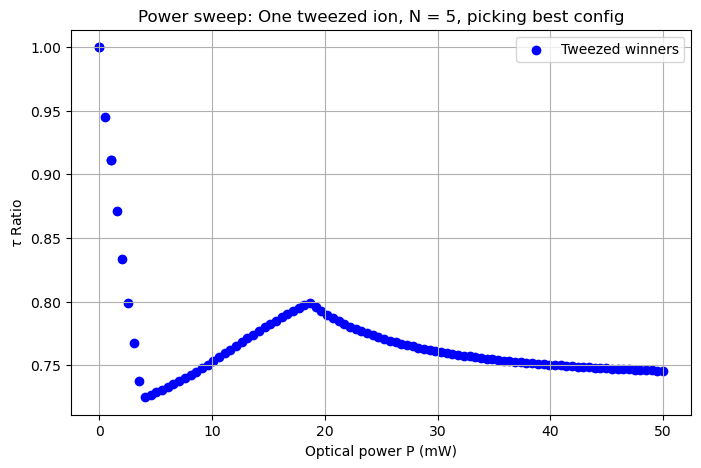

In [ ]:

P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_5 = []
for Ni in range(5, 6):
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_5.append((Ni, power_results))

# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_4: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_5:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_5[0], marker='o',color = 'blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()
#optimum power in mW


In [ ]:
P_opt_5_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_5[0])]*1e3 
print(P_opt_5_mW)

4.041323232323233


## N = 6

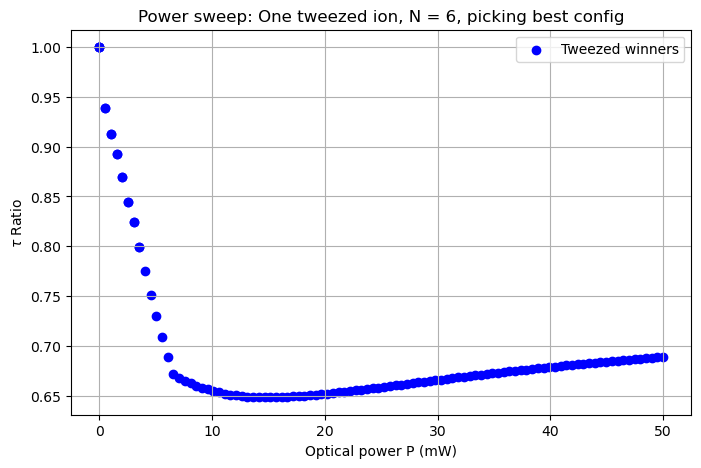

In [ ]:

P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_6 = []
for Ni in range(6, 7):
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_6.append((Ni, power_results))

# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_4: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_6:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_6[0], marker='o',color = 'blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config")
plt.grid(True)
plt.legend()
plt.show()
#optimum power in mW


In [ ]:
P_opt_6_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_6[0])]*1e3 
print(P_opt_6_mW)

15.152212121212122


In [ ]:
P_opt_list = [P_opt_2_mW,P_opt_3_mW,P_opt_4_mW,P_opt_5_mW,P_opt_6_mW,P_opt_7_mW]
print(P_opt_list)

[19.697575757575763, 7.0715656565656575, 21.71773737373738, 4.041323232323233, 15.152212121212122, 32.828626262626265]


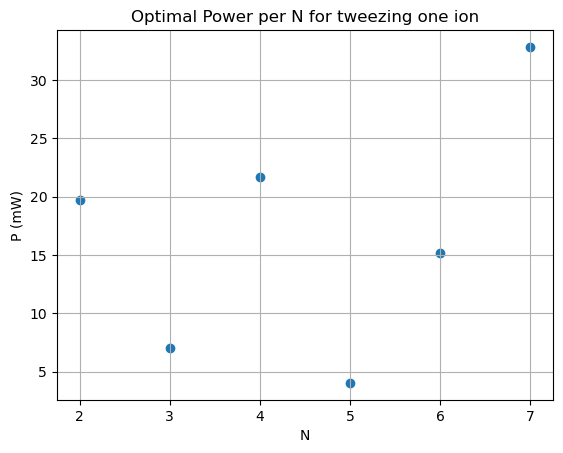

In [ ]:
plt.scatter([2,3,4,5,6,7], P_opt_list, marker='o')
plt.xlabel("N")
plt.ylabel("P (mW)")
plt.grid(True)
plt.title("Optimal Power per N for tweezing one ion")
plt.show()

## Looking at the mode-vector contributions for N=5

In [ ]:
P_opt_5_mW

4.041323232323233

In [ ]:
results_power_sweep_5

[(5,
  [(1e-06,
    [((0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06), (3, 1)),
     ((0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06), (3, 3))]),
   (0.0005060404040404041,
    [((0, (0, 4, 2, 1, 3), 0.04588650871101701, 0.0005060404040404041),
      (1, 4))]),
   (0.0010110808080808081,
    [((1, (1, 0, 4, 3, 2), 0.04756756353521739, 0.0010110808080808081),
      (4, 2)),
     ((1, (1, 4, 0, 3, 2), 0.04756756353521739, 0.0010110808080808081),
      (4, 2))]),
   (0.0015161212121212124,
    [((1, (1, 4, 0, 3, 2), 0.049760827728738175, 0.0015161212121212124),
      (4, 2))]),
   (0.0020211616161616166,
    [((1, (1, 4, 0, 3, 2), 0.051991201031655235, 0.0020211616161616166),
      (4, 2))]),
   (0.0025262020202020206,
    [((1, (1, 4, 0, 3, 2), 0.05424203654165607, 0.0025262020202020206),
      (4, 2))]),
   (0.003031242424242425,
    [((1, (1, 4, 0, 3, 2), 0.0564956163705365, 0.003031242424242425),
      (4, 2))]),
   (0.003536282828282829,
    [((1, (1, 4, 0, 3, 2), -0.05873387164819

In [ ]:
mode_vector_check_5 = tweezer_combos_full_radial_test(omega_tweezer,linewidths,omega_res,m,mode_calc_r,5,f_rf_r,f_rf_a,P_opt_5_mW,w0,max_tweezed=1)

In [ ]:
mode_vector_check_5.iloc[2]

N                                                                                                                                               5
Tweezed ions                                                                                                                                 (1,)
P_per_tweezer (W)                                                                                                                        4.041323
Combined radial frequencies                      [6283185.307179586, 14219302.127737332, 6283185.307179586, 6283185.307179586, 6283185.307179586]
Mode0_freq                                                                                                                         2260980.971775
Mode0_eigvec                   [5.646086560093666e-05, 0.06445923069864222, 7.92098942076904e-05, 1.0004826738276208e-05, 2.6314663360765735e-06]
Mode1_freq                                                                                                                  

In [ ]:
# access 'Mode2_eigvec' for the third row (index 2), tweezing 1, 
val = [
	mode_vector_check_5.iloc[2]["Mode0_eigvec"][1],
	mode_vector_check_5.iloc[2]["Mode1_eigvec"][4],
	mode_vector_check_5.iloc[2]["Mode2_eigvec"][0],
	mode_vector_check_5.iloc[2]["Mode3_eigvec"][2],
	mode_vector_check_5.iloc[2]["Mode4_eigvec"][3],
]
# round each element (round doesn't work on lists)
val_rounded = [round(float(x), 4) for x in val]
val_rounded

[0.0645, 0.0731, -0.0959, -0.059, 0.0654]

In [ ]:
#y_ref_5[0] is the untweezed reference value for N=5
(y_ref_5[0] - 1/np.min(np.abs(val)) ) / y_ref_5[0]

0.2658699125233048

## Redoing the N sweep sweep for optimal powers from N=2 to N=7

In [ ]:

w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results_optimal_power = []
for i, Ni in enumerate(range(2, 8)):
    # Use the corresponding P_opt for the current N
    P_opt = P_opt_list[i]*1e-3
    print(P_opt)
    winners = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_optimal_power.append((Ni, winners))


0.019697575757575764
0.007071565656565658
0.02171773737373738
0.004041323232323233
0.015152212121212122
0.03282862626262627


In [ ]:
results_optimal_power

[(2, [((0, (0, 1), 0.09624126522590519, 0.019697575757575764), (1, 1))]),
 (3, [((0, (0, 2, 1), -0.08251491336286615, 0.007071565656565658), (0, 0))]),
 (4, [((1, (1, 3, 0, 2), 0.08577333357960697, 0.02171773737373738), (2, 0))]),
 (5,
  [((1, (1, 4, 0, 3, 2), -0.059787040082443864, 0.004041323232323233),
    (4, 2))]),
 (6,
  [((2, (2, 5, 0, 4, 1, 3), 0.06102827283143321, 0.015152212121212122),
    (2, 0))]),
 (7,
  [((2, (2, 6, 0, 4, 1, 5, 3), -0.05500904243387041, 0.03282862626262627),
    (0, 2))])]

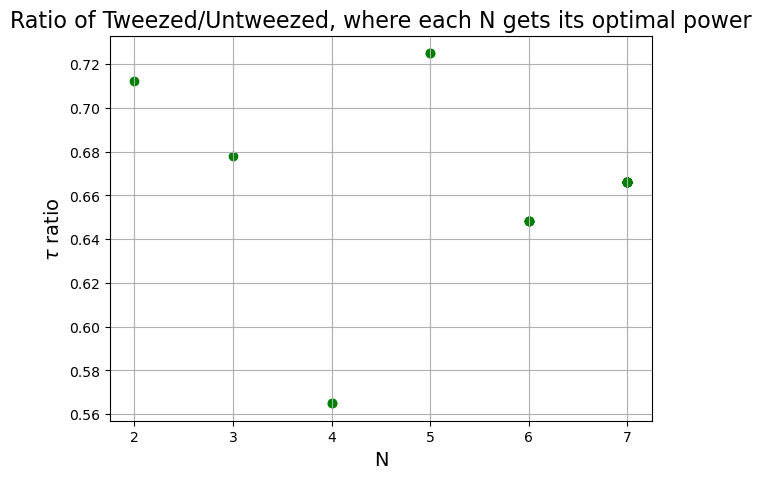

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _extract_score_from_win(win):
    """Return numeric score from a winner entry or None if not found."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), (best_ion, best_mode))
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def _extract_tweezed_ion(win):
    """Return tweezed ion index (or None) from a winner entry."""
    if not isinstance(win, (list, tuple)):
        return None
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 1:
        return win[0][0]
    return win[0]

# Tweezed winners only
x_tweezed = []
y_tweezed = []

for N_val, winners in results_optimal_power:
    if not winners:
        continue
    for win in winners:
        tweezed_ion = _extract_tweezed_ion(win)
        if tweezed_ion is None:
            continue   # skip untweezed
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_tweezed.append(N_val)
        y_tweezed.append(abs(score))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_untweezed.append(N_val)
        y_untweezed.append(abs(score))

# Convert to arrays (safe if empty)
x_tweezed = np.asarray(x_tweezed, dtype=float)
y_tweezed = np.asarray(y_tweezed, dtype=float)
x_untweezed = np.asarray(x_untweezed, dtype=float)
y_untweezed = np.asarray(y_untweezed, dtype=float)

# Calculate the ratio (1/y_tweezed) / (1/y_untweezed) = y_untweezed / y_tweezed per N
Ns = np.unique(np.concatenate((x_tweezed, x_untweezed)))
ratios = []

for N in Ns:
    tweezed_scores = y_tweezed[x_tweezed == N]
    untweezed_scores = y_untweezed[x_untweezed == N]
    if len(tweezed_scores) == 0 or len(untweezed_scores) == 0:  # Avoid division by zero
        continue
    # Compute the ratio for each untweezed score to each tweezed score
    for tweezed_score in tweezed_scores:
        for untweezed_score in untweezed_scores:
            ratios.append((N, untweezed_score / tweezed_score))

# Separate the ratios into x and y for plotting
x_ratios = np.array([r[0] for r in ratios])
y_ratios = np.array([r[1] for r in ratios])

# Plot the ratios
plt.figure(figsize=(7, 5))
plt.scatter(x_ratios, y_ratios, color='green')
plt.xlabel('N',fontsize = 14)
plt.ylabel(r'$\tau$ ratio',fontsize = 14)
plt.title(r'Ratio of Tweezed/Untweezed, where each N gets its optimal power',fontsize = 16)
plt.grid(True)
plt.show()

In [ ]:
y_ratios

array([0.71212749, 0.67817378, 0.56500434, 0.56500434, 0.72500669,
       0.72500669, 0.64837665, 0.64837665, 0.64837665, 0.64837665,
       0.66596433, 0.66596433, 0.66596433, 0.66596433, 0.66596433,
       0.66596433, 0.66596433, 0.66596433, 0.66596433, 0.66596433,
       0.66596433, 0.66596433, 0.66596433, 0.66596433, 0.66596433,
       0.66596433])

In [ ]:
import numpy as np

# print y_ratios without duplicates, preserving original order

y_ratios_P_opt = np.array(list(dict.fromkeys(y_ratios.tolist())))
print(y_ratios_P_opt)

[0.71212749 0.67817378 0.56500434 0.72500669 0.64837665 0.66596433]


In [ ]:
print(y_ratios_unique_P_4_mW[5])
print(y_ratios_P_opt[5])

0.796722391341253
0.6659643275234249
